In [1]:
import math
import time
import numpy as np
import pandas as pd
import yfinance as yf


import torch
import torch.nn as nn

from model import train_pinn


from montecarlo import mc_asian_call_arith
from montecarlo import pinn_price_real


from evaluation import evaluate_mae_pinn_vs_mc
from evaluation import parity_plot_plotly
from evaluation import run_full_evaluation


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32


## WTI Domain

In [2]:
# Get real WTI data and infer ranges

df = yf.download("CL=F", start="2010-01-01", progress=False)
prices = df["Close"].dropna()


S0 = float(prices.iloc[-1])
S_max_hist = float(prices.max())


log_ret = np.log(prices / prices.shift(1)).dropna()
sigma_hist = float(log_ret.std()) * np.sqrt(252)


T = 1.0
S_max_real = 1.2 * S_max_hist
I_max_real = S_max_real * T
sigma_max = min(1.0, 2.0 * sigma_hist)
r_max = 0.5


print("=== REAL (USD) ranges ===")
print(f"S0        = {S0:.2f}")
print(f"S_max     = {S_max_real:.2f}")
print(f"I_max     = {I_max_real:.2f}")
print(f"sigma     = {sigma_hist:.3f}")
print(f"sigma_max = {sigma_max:.3f}")
print(f"r_max     = {r_max}")


YF.download() has changed argument auto_adjust default to True
=== REAL (USD) ranges ===
S0        = 57.41
S_max     = 148.44
I_max     = 148.44
sigma     = 0.404
sigma_max = 0.807
r_max     = 0.5


/var/folders/7y/h7b4hxf568n1y6xlpl8vf6340000gn/T/ipykernel_74546/968340630.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(prices.iloc[-1])
/var/folders/7y/h7b4hxf568n1y6xlpl8vf6340000gn/T/ipykernel_74546/968340630.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S_max_hist = float(prices.max())
/opt/homebrew/lib/python3.11/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/var/folders/7y/h7b4hxf568n1y6xlpl8vf6340000gn/T/ipykernel_74546/968340630.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sigma_hist = float(log_ret.std()) * np.sqrt(252)


In [3]:
# Normalization: K_scale = S0  (so S̃0 = 1)

K_scale = S0  


S_max = S_max_real / K_scale
I_max = I_max_real / K_scale


print("\n=== NORMALIZED (dimensionless) ranges ===")
print(f"K_scale   = {K_scale:.2f}")
print(f"S0_tilde  = {S0 / K_scale:.3f}")      # should be 1.000
print(f"S_max_t   = {S_max:.3f}")
print(f"I_max_t   = {I_max:.3f}")
print(f"r_max     = {r_max:.3f}")
print(f"sigma_max = {sigma_max:.3f}")



=== NORMALIZED (dimensionless) ranges ===
K_scale   = 57.41
S0_tilde  = 1.000
S_max_t   = 2.586
I_max_t   = 2.586
r_max     = 0.500
sigma_max = 0.807


## Training

In [4]:
model = train_pinn(
   S_max, I_max, r_max, sigma_max,
   width=160,
   depth=4,
   n_epochs=50000,     # start here; increase toward 200k/500k if needed
   lr0=1e-3,
   Np=1000,
   n_bc_axis=100,
   w_pde=1.0,
   print_every=2000
)

K_real = S0  # ATM
r_eval = 0.05
sigma_eval = sigma_hist



print("Evaluation (real scale)")
test_S = [0.8*S0, 1.0*S0, 1.2*S0]  # around spot


for S_test in test_S:
   pinn_p = pinn_price_real(model, S_test, K_real, r_eval, sigma_eval, t0=0.0)
   mc_p, mc_se = mc_asian_call_arith(S_test, K_real, r_eval, sigma_eval, T=1.0, n_steps=252, n_paths=50_000, antithetic=True)


   print(f"S={S_test:8.2f} | PINN={pinn_p:10.4f} | MC={mc_p:10.4f} ± {1.645*mc_se:8.4f} (90% CI half-width)")


ep=   2000 | loss=6.603e-04 | pde=2.435e-04 | data=4.168e-04 | lr=9.96e-04 | 1.2 min
ep=   4000 | loss=2.178e-04 | pde=1.042e-04 | data=1.136e-04 | lr=9.84e-04 | 2.4 min
ep=   6000 | loss=1.044e-04 | pde=4.859e-05 | data=5.579e-05 | lr=9.65e-04 | 3.6 min
ep=   8000 | loss=2.519e-04 | pde=2.699e-05 | data=2.249e-04 | lr=9.38e-04 | 4.9 min
ep=  10000 | loss=8.010e-05 | pde=3.304e-05 | data=4.706e-05 | lr=9.05e-04 | 6.4 min
ep=  12000 | loss=3.276e-05 | pde=1.615e-05 | data=1.661e-05 | lr=8.64e-04 | 7.8 min
ep=  14000 | loss=2.592e-05 | pde=1.359e-05 | data=1.234e-05 | lr=8.19e-04 | 9.2 min
ep=  16000 | loss=1.113e-04 | pde=8.725e-06 | data=1.026e-04 | lr=7.68e-04 | 10.4 min
ep=  18000 | loss=2.109e-05 | pde=6.740e-06 | data=1.435e-05 | lr=7.13e-04 | 11.7 min
ep=  20000 | loss=2.118e-05 | pde=8.697e-06 | data=1.248e-05 | lr=6.55e-04 | 13.0 min
ep=  22000 | loss=3.167e-05 | pde=2.435e-05 | data=7.319e-06 | lr=5.94e-04 | 14.3 min
ep=  24000 | loss=4.705e-05 | pde=2.303e-05 | data=2.402e-05 

## Evaluation

In [20]:
S_grid_eval = np.linspace(0, S_max_real, 300)

results = run_full_evaluation(
    model=model,          # PINN già addestrata
    S_grid=S_grid_eval,   # grid su S
    K_real=K_real,        # strike reale
    r=r_eval,             # risk-free rate
    sigma=sigma_eval,     # volatilità
    T=1.0,                # maturità
    n_steps_mc=252,       # discretizzazione MC
    n_paths_mc=200_000,   # paths MC
    h_delta=1.0,          # bump per delta
)

Running Monte Carlo reference (prices + delta, single pass)...
MAE (PINN vs MC): 0.019105
Speed-up (MC / PINN): 19573.3x


In [5]:
S_grid_real = np.linspace(0.0, S_max_real, 250)


mae, mc_vals, pinn_vals = evaluate_mae_pinn_vs_mc(
   model=model,
   S_grid_real=S_grid_real,
   K_real=K_real,
   r=r_eval,
   sigma=sigma_eval,
   T=1.0,
   n_steps_mc=252,
   n_paths_mc=100_000
)

print(f"MAE (PINN vs MC) = {mae:.6f}")

parity_plot_plotly(
   mc_vals,
   pinn_vals,
   title="Asian Call (WTI) – PINN vs Monte Carlo"
)


Running MC reference pricing...
Evaluating PINN prices...
MAE (PINN vs MC) = 0.022036



Running MC reference pricing...
Evaluating PINN prices...
MAE (PINN vs MC) = 0.021865


Computing price and delta curves...


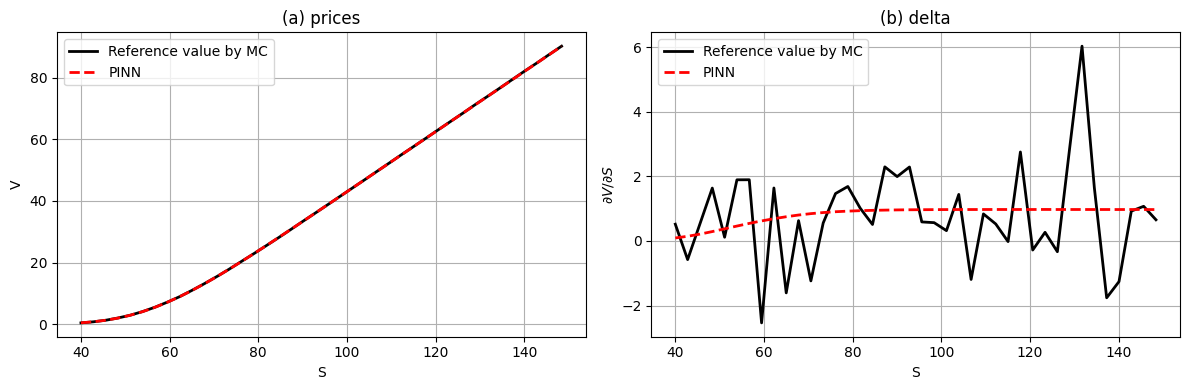

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Numerical Delta (central finite differences)
# ============================================================
def numerical_delta(price_fn, S, h=1e-2):
    return (price_fn(S + h) - price_fn(S - h)) / (2 * h)


# ============================================================
# Compute price + delta curves
# ============================================================
def compute_price_and_delta_curves(
    model,
    S_grid,
    K_real,
    r,
    sigma,
    T=1.0,
    n_steps_mc=252,
    n_paths_mc=200_000,
):
    mc_prices, pinn_prices = [], []
    mc_deltas, pinn_deltas = [], []

    print("Computing price and delta curves...")

    for S in S_grid:
        # --- Prices ---
        p_mc, _ = mc_asian_call_arith(
            S0_real=S,
            K_real=K_real,
            r=r,
            sigma=sigma,
            T=T,
            n_steps=n_steps_mc,
            n_paths=n_paths_mc,
            antithetic=True
        )

        p_pinn = pinn_price_real(
            model=model,
            S0_real=S,
            K_real=K_real,
            r=r,
            sigma=sigma,
            t0=0.0
        )

        mc_prices.append(p_mc)
        pinn_prices.append(p_pinn)

        # --- Deltas ---
        d_mc = numerical_delta(
            lambda x: mc_asian_call_arith(
                x, K_real, r, sigma, T, n_steps_mc, n_paths_mc, True
            )[0],
            S
        )

        d_pinn = numerical_delta(
            lambda x: pinn_price_real(model, x, K_real, r, sigma, 0.0),
            S
        )

        mc_deltas.append(d_mc)
        pinn_deltas.append(d_pinn)

    return (
        np.array(mc_prices),
        np.array(pinn_prices),
        np.array(mc_deltas),
        np.array(pinn_deltas),
    )


# ============================================================
# Plot: Prices and Deltas (paper-style)
# ============================================================
def plot_price_and_delta(S_grid, mc_prices, pinn_prices, mc_deltas, pinn_deltas):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # (a) Prices
    axes[0].plot(S_grid, mc_prices, "k-", lw=2, label="Reference value by MC")
    axes[0].plot(S_grid, pinn_prices, "r--", lw=2, label="PINN")
    axes[0].set_xlabel("S")
    axes[0].set_ylabel("V")
    axes[0].legend()
    axes[0].grid(True)
    axes[0].set_title("(a) prices")

    # (b) Delta
    axes[1].plot(S_grid, mc_deltas, "k-", lw=2, label="Reference value by MC")
    axes[1].plot(S_grid, pinn_deltas, "r--", lw=2, label="PINN")
    axes[1].set_xlabel("S")
    axes[1].set_ylabel(r"$\partial V / \partial S$")
    axes[1].legend()
    axes[1].grid(True)
    axes[1].set_title("(b) delta")

    plt.tight_layout()
    plt.show()


# ============================================================
# VALIDATION GRID (MAE + Parity plot)
# ============================================================
S_grid_real = np.linspace(0.0, S_max_real, 250)

mae, mc_vals, pinn_vals = evaluate_mae_pinn_vs_mc(
    model=model,
    S_grid_real=S_grid_real,
    K_real=K_real,
    r=r_eval,
    sigma=sigma_eval,
    T=1.0,
    n_steps_mc=252,
    n_paths_mc=100_000
)

print(f"MAE (PINN vs MC) = {mae:.6f}")

parity_plot_plotly(
    mc_vals,
    pinn_vals,
    title="Asian Call (WTI) – PINN vs Monte Carlo"
)


# ============================================================
# PRICE + DELTA CURVES (figure-style)
# ============================================================
S_grid_plot = np.linspace(40.0, S_max_real, 40)

mc_prices, pinn_prices, mc_deltas, pinn_deltas = compute_price_and_delta_curves(
    model=model,
    S_grid=S_grid_plot,
    K_real=K_real,
    r=r_eval,
    sigma=sigma_eval,
)

plot_price_and_delta(
    S_grid_plot,
    mc_prices,
    pinn_prices,
    mc_deltas,
    pinn_deltas
)


Benchmarking execution times...


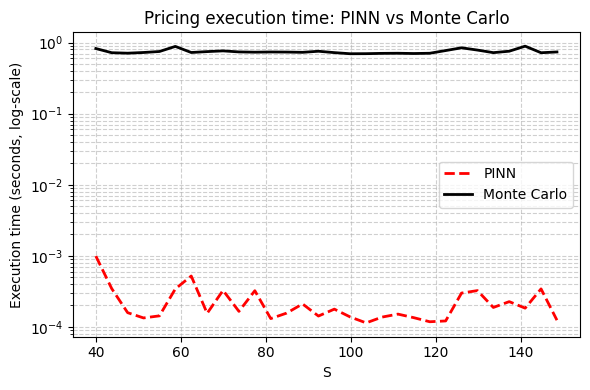

Average PINN time   : 2.337606e-04 s
Average MC time     : 7.485987e-01 s
Speed-up (MC / PINN): 4109.7x


In [8]:
import time
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Timing benchmark
# ============================================================
def benchmark_pricing_times(
    model,
    S_grid,
    K_real,
    r,
    sigma,
    T=1.0,
    n_steps_mc=252,
    n_paths_mc=100_000,
    n_repeat=5,
):
    """
    Measures average wall-clock time per pricing call.
    """
    pinn_times = []
    mc_times = []

    print("Benchmarking execution times...")

    for S in S_grid:
        # ---------- PINN timing ----------
        t_pinn = 0.0
        for _ in range(n_repeat):
            t0 = time.perf_counter()
            _ = pinn_price_real(
                model=model,
                S0_real=S,
                K_real=K_real,
                r=r,
                sigma=sigma,
                t0=0.0
            )
            t_pinn += time.perf_counter() - t0
        pinn_times.append(t_pinn / n_repeat)

        # ---------- MC timing ----------
        t_mc = 0.0
        for _ in range(n_repeat):
            t0 = time.perf_counter()
            _ = mc_asian_call_arith(
                S0_real=S,
                K_real=K_real,
                r=r,
                sigma=sigma,
                T=T,
                n_steps=n_steps_mc,
                n_paths=n_paths_mc,
                antithetic=True
            )[0]
            t_mc += time.perf_counter() - t0
        mc_times.append(t_mc / n_repeat)

    return np.array(pinn_times), np.array(mc_times)

# ============================================================
# Plot execution times
# ============================================================
def plot_execution_times(S_grid, pinn_times, mc_times):
    plt.figure(figsize=(6, 4))

    plt.plot(S_grid, pinn_times, "r--", lw=2, label="PINN")
    plt.plot(S_grid, mc_times, "k-", lw=2, label="Monte Carlo")

    plt.yscale("log")
    plt.xlabel("S")
    plt.ylabel("Execution time (seconds, log-scale)")
    plt.title("Pricing execution time: PINN vs Monte Carlo")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()
# ============================================================
# RUN TIMING EXPERIMENT
# ============================================================
S_grid_time = np.linspace(40.0, S_max_real, 30)

pinn_times, mc_times = benchmark_pricing_times(
    model=model,
    S_grid=S_grid_time,
    K_real=K_real,
    r=r_eval,
    sigma=sigma_eval,
    T=1.0,
    n_steps_mc=252,
    n_paths_mc=100_000,
    n_repeat=5,
)

plot_execution_times(
    S_grid_time,
    pinn_times,
    mc_times
)

print(f"Average PINN time   : {pinn_times.mean():.6e} s")
print(f"Average MC time     : {mc_times.mean():.6e} s")
print(f"Speed-up (MC / PINN): {(mc_times / pinn_times).mean():.1f}x")


In [6]:

# --- Train ---
model = train_pinn(
   S_max, I_max, r_max, sigma_max,
   width=160,
   depth=4,
   n_epochs=2000,     # start here; increase toward 200k/500k if needed
   lr0=1e-3,
   Np=1000,
   n_bc_axis=100,
   w_pde=1.0,
   print_every=2000
)


# --- Evaluate vs MC at a few spots ---

K_real = S0  # ATM
r_eval = 0.05
sigma_eval = sigma_hist


print("\n=== Evaluation (real scale) ===")
test_S = [0.8*S0, 1.0*S0, 1.2*S0]  # around spot


for S_test in test_S:
   pinn_p = pinn_price_real(model, S_test, K_real, r_eval, sigma_eval, t0=0.0)
   mc_p, mc_se = mc_asian_call_arith(S_test, K_real, r_eval, sigma_eval, T=1.0, n_steps=252, n_paths=50_000, antithetic=True)


   print(f"S={S_test:8.2f} | PINN={pinn_p:10.4f} | MC={mc_p:10.4f} ± {1.645*mc_se:8.4f} (90% CI half-width)")




# Grid di prezzi reali (paper usa S ∈ [0, 300])
S_grid_real = np.linspace(0.0, S_max_real, 250)


mae, mc_vals, pinn_vals = evaluate_mae_pinn_vs_mc(
   model=model,
   S_grid_real=S_grid_real,
   K_real=K_real,
   r=r_eval,
   sigma=sigma_eval,
   T=1.0,
   n_steps_mc=252,
   n_paths_mc=100_000
)


print("\n==============================")
print(f"MAE (PINN vs MC) = {mae:.6f}")
print("==============================")


parity_plot_plotly(
   mc_vals,
   pinn_vals,
   title="Asian Call (WTI) – PINN vs Monte Carlo"
)

ep=   2000 | loss=1.704e-03 | pde=6.358e-04 | data=1.069e-03 | lr=0.00e+00 | 1.1 min

=== Evaluation (real scale) ===
S=   45.94 | PINN=    2.7123 | MC=    1.3674 ±   0.0324 (90% CI half-width)
S=   57.42 | PINN=    8.8363 | MC=    5.8675 ±   0.0701 (90% CI half-width)
S=   68.90 | PINN=   16.7932 | MC=   13.9816 ±   0.1065 (90% CI half-width)

Running MC reference pricing...
Evaluating PINN prices...

MAE (PINN vs MC) = 1.463891


In [ ]:
from utils import safe_one_minus_exp_over_r
from utils import payoff_K1_T1


from model import PINN
from model import pde_residual
from model import train_pinn

from datasets import sample_domain
from datasets import sample_TC
from datasets import sample_BC_S0
from datasets import sample_BC_Smax
from datasets import sample_domain
from datasets import sample_BC_Imax


from montecarlo import mc_asian_call_arith
from montecarlo import pinn_price_real


from evaluation import evaluate_mae_pinn_vs_mc
from evaluation import parity_plot_plotly



In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Numerical Delta (central finite difference)
# ============================================================
def numerical_delta(price_fn, S, h=1e-2):
    return (price_fn(S + h) - price_fn(S - h)) / (2 * h)


# ============================================================
# Compute price + delta curves using EXISTING pricing functions
# ============================================================
def compute_price_and_delta_curves(
    model,
    S_grid,
    K_real,
    r,
    sigma,
    T=1.0,
    n_steps_mc=252,
    n_paths_mc=200_000,
):
    mc_prices, pinn_prices = [], []
    mc_deltas, pinn_deltas = [], []

    print("Computing price and delta curves...")

    for S in S_grid:
        # --- Prices ---
        p_mc, _ = mc_asian_call_arith(
            S0_real=S,
            K_real=K_real,
            r=r,
            sigma=sigma,
            T=T,
            n_steps=n_steps_mc,
            n_paths=n_paths_mc,
            antithetic=True
        )

        p_pinn = pinn_price_real(
            model=model,
            S0_real=S,
            K_real=K_real,
            r=r,
            sigma=sigma,
            t0=0.0
        )

        mc_prices.append(p_mc)
        pinn_prices.append(p_pinn)

        # --- Deltas (numerical) ---
        d_mc = numerical_delta(
            lambda x: mc_asian_call_arith(
                x, K_real, r, sigma, T, n_steps_mc, n_paths_mc, True
            )[0],
            S
        )

        d_pinn = numerical_delta(
            lambda x: pinn_price_real(model, x, K_real, r, sigma, 0.0),
            S
        )

        mc_deltas.append(d_mc)
        pinn_deltas.append(d_pinn)

    return (
        np.array(mc_prices),
        np.array(pinn_prices),
        np.array(mc_deltas),
        np.array(pinn_deltas),
    )


# ============================================================
# Plot (paper-style)
# ============================================================
def plot_price_and_delta(S_grid, mc_prices, pinn_prices, mc_deltas, pinn_deltas):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # (a) Prices
    axes[0].plot(S_grid, mc_prices, "k-", lw=2, label="Reference value by MC")
    axes[0].plot(S_grid, pinn_prices, "r--", lw=2, label="PINN")
    axes[0].set_xlabel("S")
    axes[0].set_ylabel("V")
    axes[0].legend()
    axes[0].grid(True)
    axes[0].set_title("(a) prices")

    # (b) Delta
    axes[1].plot(S_grid, mc_deltas, "k-", lw=2, label="Reference value by MC")
    axes[1].plot(S_grid, pinn_deltas, "r--", lw=2, label="PINN")
    axes[1].set_xlabel("S")
    axes[1].set_ylabel(r"$\partial V / \partial S$")
    axes[1].legend()
    axes[1].grid(True)
    axes[1].set_title("(b) delta")

    plt.tight_layout()
    plt.show()


# ============================================================
# RUN
# ============================================================
S_grid = np.linspace(40, 300, 40)   # stesso range della figura
mc_prices, pinn_prices, mc_deltas, pinn_deltas = compute_price_and_delta_curves(
    model=model,
    S_grid=S_grid,
    K_real=K_real,
    r=r,
    sigma=sigma,
)

plot_price_and_delta(
    S_grid,
    mc_prices,
    pinn_prices,
    mc_deltas,
    pinn_deltas
)


NameError: name 'r' is not defined

In [9]:
import time
import numpy as np
import torch
import plotly.graph_objects as go

from montecarlo import mc_asian_call_arith, pinn_price_real

# ============================================================
# Utils
# ============================================================
def numerical_delta_from_grid(prices, S_grid):
    """
    Central finite differences on a precomputed price grid
    """
    dS = S_grid[1] - S_grid[0]
    deltas = np.zeros_like(prices)
    deltas[1:-1] = (prices[2:] - prices[:-2]) / (2 * dS)
    deltas[0] = (prices[1] - prices[0]) / dS
    deltas[-1] = (prices[-1] - prices[-2]) / dS
    return deltas


# ============================================================
# Monte Carlo reference (computed ONCE)
# ============================================================
def compute_mc_reference(
    S_grid,
    K_real,
    r,
    sigma,
    T=1.0,
    n_steps_mc=252,
    n_paths_mc=100_000,
):
    print("Running Monte Carlo reference pricing (single pass)...")

    prices = []
    times = []

    for S in S_grid:
        t0 = time.perf_counter()
        p, _ = mc_asian_call_arith(
            S0_real=S,
            K_real=K_real,
            r=r,
            sigma=sigma,
            T=T,
            n_steps=n_steps_mc,
            n_paths=n_paths_mc,
            antithetic=True,
        )
        times.append(time.perf_counter() - t0)
        prices.append(p)

    prices = np.array(prices)
    times = np.array(times)
    deltas = numerical_delta_from_grid(prices, S_grid)

    return {
        "S": S_grid,
        "prices": prices,
        "deltas": deltas,
        "times": times,
    }


# ============================================================
# PINN evaluation (cheap, vectorized)
# ============================================================
def compute_pinn_outputs(
    model,
    S_grid,
    K_real,
    r,
    sigma,
):
    prices = []
    times = []

    for S in S_grid:
        t0 = time.perf_counter()
        p = pinn_price_real(
            model=model,
            S0_real=S,
            K_real=K_real,
            r=r,
            sigma=sigma,
            t0=0.0,
        )
        times.append(time.perf_counter() - t0)
        prices.append(p)

    prices = np.array(prices)
    times = np.array(times)
    deltas = numerical_delta_from_grid(prices, S_grid)

    return {
        "prices": prices,
        "deltas": deltas,
        "times": times,
    }


# ============================================================
# Metrics
# ============================================================
def compute_mae(mc_prices, pinn_prices):
    return np.mean(np.abs(mc_prices - pinn_prices))


# ============================================================
# Plotly figures
# ============================================================
def plot_execution_times(S, mc_times, pinn_times):
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=S, y=pinn_times,
        mode="lines+markers",
        name="PINN"
    ))

    fig.add_trace(go.Scatter(
        x=S, y=mc_times,
        mode="lines+markers",
        name="Monte Carlo"
    ))

    fig.update_layout(
        title="Pricing execution time: PINN vs Monte Carlo",
        xaxis_title="S",
        yaxis_title="Execution time (seconds, log scale)",
        yaxis_type="log",
        template="plotly_white",
    )

    fig.show()


def plot_price_and_delta(S, mc_prices, pinn_prices, mc_deltas, pinn_deltas):
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=S, y=mc_prices,
        name="MC price",
        line=dict(color="black")
    ))

    fig.add_trace(go.Scatter(
        x=S, y=pinn_prices,
        name="PINN price",
        line=dict(dash="dash", color="red")
    ))

    fig.add_trace(go.Scatter(
        x=S, y=mc_deltas,
        name="MC delta",
        yaxis="y2",
        line=dict(color="black", dash="dot")
    ))

    fig.add_trace(go.Scatter(
        x=S, y=pinn_deltas,
        name="PINN delta",
        yaxis="y2",
        line=dict(color="red", dash="dot")
    ))

    fig.update_layout(
        title="Asian option price and delta",
        xaxis_title="S",
        yaxis=dict(title="Price"),
        yaxis2=dict(
            title="Delta",
            overlaying="y",
            side="right"
        ),
        template="plotly_white",
    )

    fig.show()


def parity_plot_plotly(mc_prices, pinn_prices, title):
    lim_min = min(mc_prices.min(), pinn_prices.min())
    lim_max = max(mc_prices.max(), pinn_prices.max())

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=mc_prices,
        y=pinn_prices,
        mode="markers",
        name="Observations",
    ))

    fig.add_trace(go.Scatter(
        x=[lim_min, lim_max],
        y=[lim_min, lim_max],
        mode="lines",
        name="y = x",
        line=dict(dash="dash"),
    ))

    fig.update_layout(
        title=title,
        xaxis_title="Monte Carlo price",
        yaxis_title="PINN price",
        xaxis=dict(scaleanchor="y", scaleratio=1),
        template="plotly_white",
        width=600,
        height=600,
    )

    fig.show()


# ============================================================
# MASTER evaluation entry point
# ============================================================
def run_full_evaluation(
    model,
    S_grid,
    K_real,
    r,
    sigma,
    T=1.0,
    n_steps_mc=252,
    n_paths_mc=100_000,
):
    mc = compute_mc_reference(
        S_grid=S_grid,
        K_real=K_real,
        r=r,
        sigma=sigma,
        T=T,
        n_steps_mc=n_steps_mc,
        n_paths_mc=n_paths_mc,
    )

    pinn = compute_pinn_outputs(
        model=model,
        S_grid=S_grid,
        K_real=K_real,
        r=r,
        sigma=sigma,
    )

    mae = compute_mae(mc["prices"], pinn["prices"])

    print(f"MAE (PINN vs MC): {mae:.6e}")
    print(f"Speed-up (MC / PINN): {(mc['times'] / pinn['times']).mean():.1f}x")

    plot_execution_times(S_grid, mc["times"], pinn["times"])
    plot_price_and_delta(
        S_grid,
        mc["prices"],
        pinn["prices"],
        mc["deltas"],
        pinn["deltas"],
    )
    parity_plot_plotly(
        mc["prices"],
        pinn["prices"],
        title="Asian Call (WTI) – PINN vs Monte Carlo",
    )

    return {
        "mae": mae,
        "mc": mc,
        "pinn": pinn,
    }


In [10]:
S_grid = np.linspace(40.0, S_max_real, 40)

results = run_full_evaluation(
    model=model,
    S_grid=S_grid,
    K_real=K_real,
    r=r_eval,
    sigma=sigma_eval,
    T=1.0,
    n_steps_mc=252,
    n_paths_mc=100_000,
)

Running Monte Carlo reference pricing (single pass)...
MAE (PINN vs MC): 1.997359e-02
Speed-up (MC / PINN): 8631.4x


Computing price and delta curves (MC delta with CRN)...


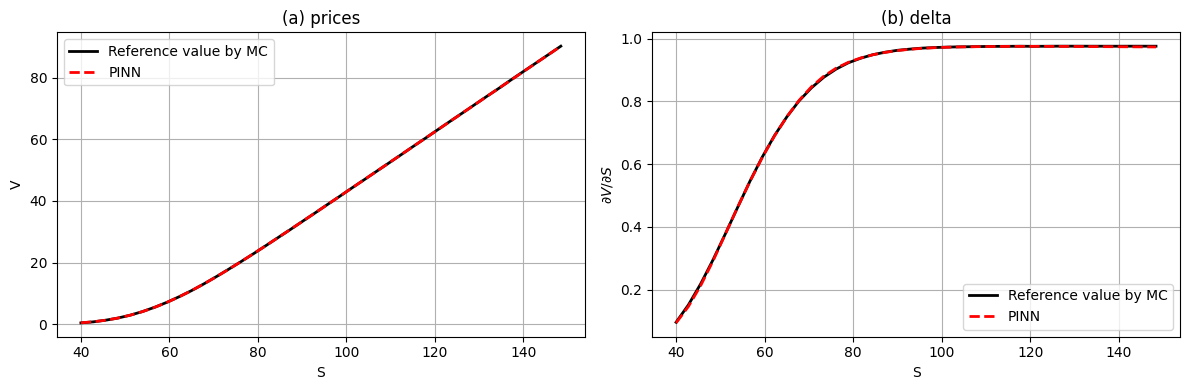

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import math

# ============================================================
# Numerical Delta (generic, used for PINN)
# ============================================================
def numerical_delta(price_fn, S, h=1.0):
    return (price_fn(S + h) - price_fn(S - h)) / (2.0 * h)


# ============================================================
# Monte Carlo Delta with Common Random Numbers (CRN)
# ============================================================
def mc_delta_crn(
    S0_real,
    K_real,
    r,
    sigma,
    T=1.0,
    n_steps=252,
    n_paths=200_000,
    h=1.0,   # bump in REAL scale
):
    dt = T / n_steps
    disc = math.exp(-r * T)

    # Common random numbers + antithetic
    half = n_paths // 2
    Z = np.random.normal(size=(half, n_steps))
    Z = np.vstack([Z, -Z])

    drift = (r - 0.5 * sigma**2) * dt
    vol = sigma * math.sqrt(dt)

    def price_given_S(S0):
        S = np.full((Z.shape[0],), S0, dtype=float)
        sumS = np.zeros_like(S)

        for k in range(n_steps):
            S *= np.exp(drift + vol * Z[:, k])
            sumS += S

        A = sumS / n_steps
        payoff = np.maximum(A - K_real, 0.0)
        return disc * payoff.mean()

    V_plus = price_given_S(S0_real + h)
    V_minus = price_given_S(S0_real - h)

    return (V_plus - V_minus) / (2.0 * h)


# ============================================================
# Compute price + delta curves
# ============================================================
def compute_price_and_delta_curves(
    model,
    S_grid,
    K_real,
    r,
    sigma,
    T=1.0,
    n_steps_mc=252,
    n_paths_mc=200_000,
):
    mc_prices, pinn_prices = [], []
    mc_deltas, pinn_deltas = [], []

    print("Computing price and delta curves (MC delta with CRN)...")

    for S in S_grid:
        # --- Prices ---
        p_mc, _ = mc_asian_call_arith(
            S0_real=S,
            K_real=K_real,
            r=r,
            sigma=sigma,
            T=T,
            n_steps=n_steps_mc,
            n_paths=n_paths_mc,
            antithetic=True
        )

        p_pinn = pinn_price_real(
            model=model,
            S0_real=S,
            K_real=K_real,
            r=r,
            sigma=sigma,
            t0=0.0
        )

        mc_prices.append(p_mc)
        pinn_prices.append(p_pinn)

        # --- Deltas ---
        d_mc = mc_delta_crn(
            S0_real=S,
            K_real=K_real,
            r=r,
            sigma=sigma,
            T=T,
            n_steps=n_steps_mc,
            n_paths=n_paths_mc,
            h=1.0
        )

        d_pinn = numerical_delta(
            lambda x: pinn_price_real(model, x, K_real, r, sigma, 0.0),
            S,
            h=1.0
        )

        mc_deltas.append(d_mc)
        pinn_deltas.append(d_pinn)

    return (
        np.array(mc_prices),
        np.array(pinn_prices),
        np.array(mc_deltas),
        np.array(pinn_deltas),
    )


# ============================================================
# Plot: Prices and Deltas (paper-style)
# ============================================================
def plot_price_and_delta(S_grid, mc_prices, pinn_prices, mc_deltas, pinn_deltas):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # (a) Prices
    axes[0].plot(S_grid, mc_prices, "k-", lw=2, label="Reference value by MC")
    axes[0].plot(S_grid, pinn_prices, "r--", lw=2, label="PINN")
    axes[0].set_xlabel("S")
    axes[0].set_ylabel("V")
    axes[0].legend()
    axes[0].grid(True)
    axes[0].set_title("(a) prices")

    # (b) Delta
    axes[1].plot(S_grid, mc_deltas, "k-", lw=2, label="Reference value by MC")
    axes[1].plot(S_grid, pinn_deltas, "r--", lw=2, label="PINN")
    axes[1].set_xlabel("S")
    axes[1].set_ylabel(r"$\partial V / \partial S$")
    axes[1].legend()
    axes[1].grid(True)
    axes[1].set_title("(b) delta")

    plt.tight_layout()
    plt.show()


# ============================================================
# RUN
# ============================================================
S_grid_plot = np.linspace(40.0, S_max_real, 40)

mc_prices, pinn_prices, mc_deltas, pinn_deltas = compute_price_and_delta_curves(
    model=model,
    S_grid=S_grid_plot,
    K_real=K_real,
    r=r_eval,
    sigma=sigma_eval,
    T=1.0,
    n_steps_mc=252,
    n_paths_mc=200_000,
)

plot_price_and_delta(
    S_grid_plot,
    mc_prices,
    pinn_prices,
    mc_deltas,
    pinn_deltas
)


In [12]:
import time
import math
import numpy as np
import plotly.graph_objects as go

from montecarlo import mc_asian_call_arith, pinn_price_real


# ============================================================
# Numerical Delta (generic, used for PINN)
# ============================================================
def numerical_delta(price_fn, S, h=1.0):
    return (price_fn(S + h) - price_fn(S - h)) / (2.0 * h)


# ============================================================
# Monte Carlo Delta with Common Random Numbers (CRN)
# ============================================================
def mc_delta_crn(
    S0_real,
    K_real,
    r,
    sigma,
    T=1.0,
    n_steps=252,
    n_paths=200_000,
    h=1.0,
):
    dt = T / n_steps
    disc = math.exp(-r * T)

    # --- Common random numbers + antithetic ---
    half = n_paths // 2
    Z = np.random.normal(size=(half, n_steps))
    Z = np.vstack([Z, -Z])

    drift = (r - 0.5 * sigma**2) * dt
    vol = sigma * math.sqrt(dt)

    def price_given_S(S0):
        S = np.full((Z.shape[0],), S0, dtype=float)
        sumS = np.zeros_like(S)

        for k in range(n_steps):
            S *= np.exp(drift + vol * Z[:, k])
            sumS += S

        A = sumS / n_steps
        payoff = np.maximum(A - K_real, 0.0)
        return disc * payoff.mean()

    V_plus = price_given_S(S0_real + h)
    V_minus = price_given_S(S0_real - h)

    return (V_plus - V_minus) / (2.0 * h)


# ============================================================
# Compute price + delta curves
# ============================================================
def compute_price_and_delta_curves(
    model,
    S_grid,
    K_real,
    r,
    sigma,
    T=1.0,
    n_steps_mc=252,
    n_paths_mc=200_000,
    h_delta=1.0,
):
    mc_prices = []
    pinn_prices = []
    mc_deltas = []
    pinn_deltas = []

    print("Computing price and delta curves (MC delta with CRN)...")

    for S in S_grid:
        # ---------------- Prices ----------------
        p_mc, _ = mc_asian_call_arith(
            S0_real=S,
            K_real=K_real,
            r=r,
            sigma=sigma,
            T=T,
            n_steps=n_steps_mc,
            n_paths=n_paths_mc,
            antithetic=True,
        )

        p_pinn = pinn_price_real(
            model=model,
            S0_real=S,
            K_real=K_real,
            r=r,
            sigma=sigma,
            t0=0.0,
        )

        mc_prices.append(p_mc)
        pinn_prices.append(p_pinn)

        # ---------------- Deltas ----------------
        d_mc = mc_delta_crn(
            S0_real=S,
            K_real=K_real,
            r=r,
            sigma=sigma,
            T=T,
            n_steps=n_steps_mc,
            n_paths=n_paths_mc,
            h=h_delta,
        )

        d_pinn = numerical_delta(
            lambda x: pinn_price_real(model, x, K_real, r, sigma, 0.0),
            S,
            h=h_delta,
        )

        mc_deltas.append(d_mc)
        pinn_deltas.append(d_pinn)

    return (
        np.asarray(mc_prices),
        np.asarray(pinn_prices),
        np.asarray(mc_deltas),
        np.asarray(pinn_deltas),
    )


# ============================================================
# Plot: Prices (Plotly)
# ============================================================
def plot_prices_plotly(S, mc_prices, pinn_prices):
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=S,
        y=mc_prices,
        name="Reference value by MC",
        line=dict(color="black"),
    ))

    fig.add_trace(go.Scatter(
        x=S,
        y=pinn_prices,
        name="PINN",
        line=dict(color="red", dash="dash"),
    ))

    fig.update_layout(
        title="(a) Asian option prices",
        xaxis_title="S",
        yaxis_title="V",
        template="plotly_white",
    )

    fig.show()


# ============================================================
# Plot: Deltas (Plotly)
# ============================================================
def plot_deltas_plotly(S, mc_deltas, pinn_deltas):
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=S,
        y=mc_deltas,
        name="Reference value by MC",
        line=dict(color="black"),
    ))

    fig.add_trace(go.Scatter(
        x=S,
        y=pinn_deltas,
        name="PINN",
        line=dict(color="red", dash="dash"),
    ))

    fig.update_layout(
        title="(b) Asian option delta",
        xaxis_title="S",
        yaxis_title="∂V / ∂S",
        template="plotly_white",
    )

    fig.show()


# ============================================================
# RUN
# ============================================================
S_grid_plot = np.linspace(40.0, S_max_real, 40)

mc_prices, pinn_prices, mc_deltas, pinn_deltas = compute_price_and_delta_curves(
    model=model,
    S_grid=S_grid_plot,
    K_real=K_real,
    r=r_eval,
    sigma=sigma_eval,
    T=1.0,
    n_steps_mc=252,
    n_paths_mc=200_000,
    h_delta=1.0,
)

plot_prices_plotly(
    S_grid_plot,
    mc_prices,
    pinn_prices,
)

plot_deltas_plotly(
    S_grid_plot,
    mc_deltas,
    pinn_deltas,
)


Computing price and delta curves (MC delta with CRN)...


KeyboardInterrupt: 

In [17]:
import time
import math
import numpy as np
import plotly.graph_objects as go

from montecarlo import mc_asian_call_arith, pinn_price_real


# ============================================================
# Numerical Delta (generic, for PINN)
# ============================================================
def numerical_delta(price_fn, S, h=1.0):
    return (price_fn(S + h) - price_fn(S - h)) / (2.0 * h)


# ============================================================
# Monte Carlo Delta with Common Random Numbers (CRN)
# ============================================================
def mc_delta_crn(
    S0_real,
    K_real,
    r,
    sigma,
    T=1.0,
    n_steps=252,
    n_paths=200_000,
    h=1.0,
):
    dt = T / n_steps
    disc = math.exp(-r * T)

    # CRN + antithetic
    half = n_paths // 2
    Z = np.random.normal(size=(half, n_steps))
    Z = np.vstack([Z, -Z])

    drift = (r - 0.5 * sigma**2) * dt
    vol = sigma * math.sqrt(dt)

    def price_given_S(S0):
        S = np.full(Z.shape[0], S0, dtype=float)
        sumS = np.zeros_like(S)

        for k in range(n_steps):
            S *= np.exp(drift + vol * Z[:, k])
            sumS += S

        A = sumS / n_steps
        payoff = np.maximum(A - K_real, 0.0)
        return disc * payoff.mean()

    V_plus = price_given_S(S0_real + h)
    V_minus = price_given_S(S0_real - h)

    return (V_plus - V_minus) / (2.0 * h)


# ============================================================
# Monte Carlo reference (prices + delta + timing) – ONCE
# ============================================================
def compute_mc_reference(
    S_grid,
    K_real,
    r,
    sigma,
    T=1.0,
    n_steps_mc=252,
    n_paths_mc=200_000,
    h_delta=1.0,
):
    print("Running Monte Carlo reference (prices + delta, single pass)...")

    prices = []
    deltas = []
    times = []

    for S in S_grid:
        # ---- price ----
        t0 = time.perf_counter()
        p, _ = mc_asian_call_arith(
            S0_real=S,
            K_real=K_real,
            r=r,
            sigma=sigma,
            T=T,
            n_steps=n_steps_mc,
            n_paths=n_paths_mc,
            antithetic=True,
        )
        times.append(time.perf_counter() - t0)
        prices.append(p)

        # ---- delta (CRN) ----
        d = mc_delta_crn(
            S0_real=S,
            K_real=K_real,
            r=r,
            sigma=sigma,
            T=T,
            n_steps=n_steps_mc,
            n_paths=n_paths_mc,
            h=h_delta,
        )
        deltas.append(d)

    return {
        "S": np.asarray(S_grid),
        "prices": np.asarray(prices),
        "deltas": np.asarray(deltas),
        "times": np.asarray(times),
    }


# ============================================================
# PINN outputs (prices + delta + timing)
# ============================================================
def compute_pinn_outputs(
    model,
    S_grid,
    K_real,
    r,
    sigma,
    h_delta=1.0,
):
    prices = []
    deltas = []
    times = []

    for S in S_grid:
        # ---- price ----
        t0 = time.perf_counter()
        p = pinn_price_real(
            model=model,
            S0_real=S,
            K_real=K_real,
            r=r,
            sigma=sigma,
            t0=0.0,
        )
        times.append(time.perf_counter() - t0)
        prices.append(p)

        # ---- delta (finite diff) ----
        d = numerical_delta(
            lambda x: pinn_price_real(model, x, K_real, r, sigma, 0.0),
            S,
            h=h_delta,
        )
        deltas.append(d)

    return {
        "prices": np.asarray(prices),
        "deltas": np.asarray(deltas),
        "times": np.asarray(times),
    }

from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np


def plot_price_delta_parity_row(
    S,
    mc_prices,
    pinn_prices,
    mc_deltas,
    pinn_deltas,
):
    # limiti per parity plot (asse x da 0)
    parity_max = max(mc_prices.max(), pinn_prices.max())

    fig = make_subplots(
        rows=1,
        cols=3,
        subplot_titles=(
            "Asian option price",
            "Asian option delta",
            "Parity plot: PINN vs Monte Carlo",
        ),
    )

    # ==================================================
    # (1) PRICE
    # ==================================================
    fig.add_trace(
        go.Scatter(
            x=S,
            y=mc_prices,
            name="Monte Carlo",
            line=dict(color="blue"),
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Scatter(
            x=S,
            y=pinn_prices,
            name="PINN",
            line=dict(color="red", dash="dash"),
        ),
        row=1,
        col=1,
    )

    # ==================================================
    # (2) DELTA
    # ==================================================
    fig.add_trace(
        go.Scatter(
            x=S,
            y=mc_deltas,
            name="Monte Carlo",
            line=dict(color="blue"),
            showlegend=False,
        ),
        row=1,
        col=2,
    )

    fig.add_trace(
        go.Scatter(
            x=S,
            y=pinn_deltas,
            name="PINN",
            line=dict(color="red", dash="dash"),
            showlegend=False,
        ),
        row=1,
        col=2,
    )

    # ==================================================
    # (3) PARITY PLOT
    # ==================================================
    fig.add_trace(
        go.Scatter(
            x=mc_prices,
            y=pinn_prices,
            mode="markers",
            name="Observations",
            marker=dict(size=6),
            showlegend=False,
        ),
        row=1,
        col=3,
    )

    fig.add_trace(
        go.Scatter(
            x=[0, parity_max],
            y=[0, parity_max],
            mode="lines",
            name="y = x",
            line=dict(color="black", dash="dash"),
            showlegend=False,
        ),
        row=1,
        col=3,
    )

    # ==================================================
    # AXES
    # ==================================================
    fig.update_xaxes(title_text="S", row=1, col=1)
    fig.update_yaxes(title_text="V", row=1, col=1)

    fig.update_xaxes(title_text="S", row=1, col=2)
    fig.update_yaxes(title_text="∂V / ∂S", row=1, col=2)

    fig.update_xaxes(
        title_text="Monte Carlo price",
        range=[0, parity_max],
        row=1,
        col=3,
    )
    fig.update_yaxes(
        title_text="PINN price",
        range=[0, parity_max],
        row=1,
        col=3,
        scaleanchor="x",
        scaleratio=1,
    )

    # ==================================================
    # LAYOUT
    # ==================================================
    fig.update_layout(
        template="plotly_white",
        width=1500,
        height=420,
        legend=dict(
            orientation="h",
            x=0.5,
            y=-0.25,
            xanchor="center",
        ),
    )

    fig.show()



# ============================================================
# Metrics
# ============================================================
def compute_mae(mc_prices, pinn_prices):
    return float(np.mean(np.abs(mc_prices - pinn_prices)))


# ============================================================
# Plotly figures
# ============================================================
def plot_prices(S, mc_prices, pinn_prices):
    fig = go.Figure()

    fig.add_trace(go.Scatter(x=S, y=mc_prices, name="Monte Carlo"))
    fig.add_trace(go.Scatter(x=S, y=pinn_prices, name="PINN", line=dict(dash="dash")))

    fig.update_layout(
        title="Asian option price",
        xaxis_title="S",
        yaxis_title="V",
        template="plotly_white",
    )
    fig.show()


def plot_deltas(S, mc_deltas, pinn_deltas):
    fig = go.Figure()

    fig.add_trace(go.Scatter(x=S, y=mc_deltas, name="Monte Carlo"))
    fig.add_trace(go.Scatter(x=S, y=pinn_deltas, name="PINN", line=dict(dash="dash")))

    fig.update_layout(
        title="Asian option delta",
        xaxis_title="S",
        yaxis_title="∂V / ∂S",
        template="plotly_white",
    )
    fig.show()


def plot_execution_times(S, mc_times, pinn_times):
    fig = go.Figure()

    fig.add_trace(go.Scatter(x=S, y=pinn_times, name="PINN"))
    fig.add_trace(go.Scatter(x=S, y=mc_times, name="Monte Carlo"))

    fig.update_layout(
        title="Pricing execution time",
        xaxis_title="S",
        yaxis_title="Execution time (seconds, log scale)",
        yaxis_type="log",
        template="plotly_white",
    )
    fig.show()


def parity_plot(mc_prices, pinn_prices):
    lim_min = min(mc_prices.min(), pinn_prices.min())
    lim_max = max(mc_prices.max(), pinn_prices.max())

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=mc_prices, y=pinn_prices, mode="markers"))
    fig.add_trace(go.Scatter(
        x=[lim_min, lim_max],
        y=[lim_min, lim_max],
        mode="lines",
        line=dict(dash="dash"),
        name="y = x",
    ))

    fig.update_layout(
        title="Parity plot: PINN vs Monte Carlo",
        xaxis_title="Monte Carlo price",
        yaxis_title="PINN price",
        xaxis=dict(scaleanchor="y", scaleratio=1),
        template="plotly_white",
    )
    fig.show()

from plotly.subplots import make_subplots
import plotly.graph_objects as go


def plot_price_and_delta_side_by_side(
    S,
    mc_prices,
    pinn_prices,
    mc_deltas,
    pinn_deltas,
):
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=(
            "Asian option price",
            "Asian option delta",
        ),
    )

    # =====================
    # (a) Price
    # =====================
    fig.add_trace(
        go.Scatter(
            x=S,
            y=mc_prices,
            name="Monte Carlo",
            line=dict(color="blue"),
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Scatter(
            x=S,
            y=pinn_prices,
            name="PINN",
            line=dict(color="red", dash="dash"),
        ),
        row=1,
        col=1,
    )

    # =====================
    # (b) Delta
    # =====================
    fig.add_trace(
        go.Scatter(
            x=S,
            y=mc_deltas,
            name="Monte Carlo",
            line=dict(color="blue"),
            showlegend=False,  # legenda già mostrata a sinistra
        ),
        row=1,
        col=2,
    )

    fig.add_trace(
        go.Scatter(
            x=S,
            y=pinn_deltas,
            name="PINN",
            line=dict(color="red", dash="dash"),
            showlegend=False,
        ),
        row=1,
        col=2,
    )

    # =====================
    # Layout
    # =====================
    fig.update_xaxes(title_text="S", row=1, col=1)
    fig.update_xaxes(title_text="S", row=1, col=2)

    fig.update_yaxes(title_text="V", row=1, col=1)
    fig.update_yaxes(title_text="∂V / ∂S", row=1, col=2)

    fig.update_layout(
        template="plotly_white",
        width=1100,
        height=420,
        legend=dict(
            x=0.5,
            y=-0.15,
            orientation="h",
            xanchor="center",
        ),
    )

    fig.show()



# ============================================================
# MASTER evaluation entry point
# ============================================================
def run_full_evaluation(
    model,
    S_grid,
    K_real,
    r,
    sigma,
    T=1.0,
    n_steps_mc=252,
    n_paths_mc=200_000,
    h_delta=1.0,
):
    mc = compute_mc_reference(
        S_grid=S_grid,
        K_real=K_real,
        r=r,
        sigma=sigma,
        T=T,
        n_steps_mc=n_steps_mc,
        n_paths_mc=n_paths_mc,
        h_delta=h_delta,
    )

    pinn = compute_pinn_outputs(
        model=model,
        S_grid=S_grid,
        K_real=K_real,
        r=r,
        sigma=sigma,
        h_delta=h_delta,
    )

    mae = compute_mae(mc["prices"], pinn["prices"])

    print(f"MAE (PINN vs MC): {mae:.6f}")
    print(f"Speed-up (MC / PINN): {(mc['times'] / pinn['times']).mean():.1f}x")

    plot_execution_times(S_grid, mc["times"], pinn["times"])
    plot_price_delta_parity_row(
    S_grid,
    mc["prices"],
    pinn["prices"],
    mc["deltas"],
    pinn["deltas"],
)


    return {
        "mae": mae,
        "mc": mc,
        "pinn": pinn,
    }


In [19]:
S_grid_eval = np.linspace(0, S_max_real, 100)

results = run_full_evaluation(
    model=model,          # PINN già addestrata
    S_grid=S_grid_eval,   # grid su S
    K_real=K_real,        # strike reale
    r=r_eval,             # risk-free rate
    sigma=sigma_eval,     # volatilità
    T=1.0,                # maturità
    n_steps_mc=252,       # discretizzazione MC
    n_paths_mc=200_000,   # paths MC
    h_delta=1.0,          # bump per delta
)

Running Monte Carlo reference (prices + delta, single pass)...
MAE (PINN vs MC): 0.018376
Speed-up (MC / PINN): 18804.9x
